In [15]:
# ============================================
# 1. Import Data
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_500_siswa_variatif_smk_B.csv')
print("Dataset shape:", df.shape)
print(df.head())
print("\nInformasi dataset:")
print(df.info())

Dataset shape: (500, 17)
   jam_belajar_perhari  persentase_kehadiran  nilai_rata_rata_rapor  \
0                  2.2                    71                     77   
1                  2.9                    79                     72   
2                  3.5                    71                     75   
3                  3.3                    77                     80   
4                  4.7                    93                     76   

   skor_time_management  jam_tidur  stress_level  screen_time  \
0                    75        6.4             6          3.2   
1                    49        4.0            20          8.2   
2                    35        6.4            10          6.1   
3                    65        6.8             5          6.6   
4                    59        8.0             5          4.4   

   kehadiran_pelatihan_industri  motivasi_akademik  exam_score gender  \
0                            40                 30          55      P   
1          

In [16]:

# ============================================
# 2. Preprocessing – Missing Values
# ============================================
# Melihat missing values
print("Missing values per kolom:\n", df.isnull().sum())

# Imputasi: median untuk numerik, modus untuk kategorikal
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Numerik
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Kategorikal
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values setelah imputasi:\n", df.isnull().sum())

Missing values per kolom:
 jam_belajar_perhari             0
persentase_kehadiran            0
nilai_rata_rata_rapor           0
skor_time_management            0
jam_tidur                       0
stress_level                    0
screen_time                     0
kehadiran_pelatihan_industri    0
motivasi_akademik               0
exam_score                      0
gender                          0
pendapatan_keluarga             0
edukasi_ortu                    0
kerja_sampingan                 0
study_environment               0
kompetensi_skill_level          0
industry_ready                  0
dtype: int64
Missing values setelah imputasi:
 jam_belajar_perhari             0
persentase_kehadiran            0
nilai_rata_rata_rapor           0
skor_time_management            0
jam_tidur                       0
stress_level                    0
screen_time                     0
kehadiran_pelatihan_industri    0
motivasi_akademik               0
exam_score                      0
gender  

In [17]:
# ============================================
# 3. Preprocessing – Outlier (capping IQR)
# ============================================
# Hanya untuk variabel numerik (kecuali target exam_score?
# Kita cap juga, tapi lebih baik target tidak dicap karena akan mempengaruhi distribusi nyata.
# Di sini kita cap fitur numerik saja.
outlier_capped_cols = []
for col in numeric_cols:
    if col != 'exam_score':  # jangan cap target
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Capping pada persentil 1 dan 99 (opsional, lebih lembut)
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
        outlier_capped_cols.append(col)

print(f"Outlier capped untuk kolom: {outlier_capped_cols}")

Outlier capped untuk kolom: ['jam_belajar_perhari', 'persentase_kehadiran', 'nilai_rata_rata_rapor', 'skor_time_management', 'jam_tidur', 'stress_level', 'screen_time', 'kehadiran_pelatihan_industri', 'motivasi_akademik']


In [18]:
# ============================================
# 4. Preprocessing – Encoding (Ordinal + One-Hot)
# ============================================
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Definisikan urutan untuk ordinal encoding
ordinal_mappings = {
    'pendapatan_keluarga': ['<1jt', '1-3jt', '3-5jt', '>5jt'],
    'edukasi_ortu': ['SD', 'SMP', 'SMA', 'D3/S1', '>S1'],
    'study_environment': ['buruk', 'cukup', 'baik', 'sangat_baik'],
    'kompetensi_skill_level': ['pemula', 'menengah', 'mahir']
}

# Kolom nominal (one-hot encoding)
nominal_cols = ['gender', 'kerja_sampingan', 'industry_ready']

# Salin dataframe untuk diproses
df_encoded = df.copy()

# Ordinal encoding
for col, categories in ordinal_mappings.items():
    oe = OrdinalEncoder(categories=[categories])
    df_encoded[col] = oe.fit_transform(df_encoded[[col]]).astype(int)

# One-hot encoding (hasilnya akan menjadi kolom baru)
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=False)

print("Shape setelah encoding:", df_encoded.shape)
print("Kolom baru one-hot:", [c for c in df_encoded.columns if any(nom in c for nom in nominal_cols)])

# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop('exam_score', axis=1)
y = df_encoded['exam_score']

# Simpan nama fitur untuk keperluan SHAP
feature_names = X.columns.tolist()
print("Jumlah fitur setelah encoding:", len(feature_names))

Shape setelah encoding: (500, 20)
Kolom baru one-hot: ['gender_L', 'gender_P', 'kerja_sampingan_tidak', 'kerja_sampingan_ya', 'industry_ready_belum_siap', 'industry_ready_siap']
Jumlah fitur setelah encoding: 19


In [19]:
# ============================================
# 5. Preprocessing – Normalisasi (StandardScaler)
# ============================================
from sklearn.preprocessing import StandardScaler

# Identifikasi kolom numerik asli + kolom hasil ordinal (yang merupakan integer)
# Secara praktis, semua kolom selain hasil one-hot adalah numerik/ordinal.
# Untuk sederhananya, kita scaler semua fitur (termasuk ordinal) karena range-nya berbeda.
# Kecuali kolom one-hot (0/1) biasanya tidak perlu discaler, tapi tidak masalah.
# Kita lakukan scaling pada semua fitur untuk perbandingan dengan/ tanpa scaler.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("StandardScaler fit selesai. Mean mendekati 0, std=1.")



StandardScaler fit selesai. Mean mendekati 0, std=1.


In [20]:
# ============================================
# 6. Pembagian Data (Stratified split berdasarkan kategorisasi risiko)
# ============================================
from sklearn.model_selection import train_test_split

# Buat kategori risiko dari y (asli)
risk = (y >= 70).astype(int)   # 1 = rendah, 0 = tinggi

# Split dengan stratifikasi berdasarkan risk
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=risk
)

print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Perbaikan: hitung distribusi risiko dari y_train dan y_test langsung
y_train_risk = (y_train >= 70).astype(int)
y_test_risk = (y_test >= 70).astype(int)

print(f"Distribusi risiko train (0=Tinggi, 1=Rendah): {y_train_risk.value_counts().to_dict()}")
print(f"Distribusi risiko test  (0=Tinggi, 1=Rendah): {y_test_risk.value_counts().to_dict()}")

# Simpan juga versi tanpa scaling untuk perbandingan nanti
# Gunakan indeks dari train_test_split awal (tanpa scaling)
_, _, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=risk
)
# Cara lebih aman: simpan indeks dari split
indices = np.arange(len(X))
train_idx, test_idx, _, _ = train_test_split(
    indices, y, test_size=0.2, random_state=42, stratify=risk
)
X_train_no_scaler = X.iloc[train_idx]
X_test_no_scaler = X.iloc[test_idx]
y_train_no_scaler = y.iloc[train_idx]
y_test_no_scaler = y.iloc[test_idx]

print(f"Shape X_train_no_scaler: {X_train_no_scaler.shape}")
print(f"Shape X_test_no_scaler: {X_test_no_scaler.shape}")

Training size: 400, Test size: 100
Distribusi risiko train (0=Tinggi, 1=Rendah): {0: 360, 1: 40}
Distribusi risiko test  (0=Tinggi, 1=Rendah): {0: 90, 1: 10}
Shape X_train_no_scaler: (400, 19)
Shape X_test_no_scaler: (100, 19)


In [21]:
# ============================================
# 7. Algoritma Random Forest (Regresi)
# ============================================
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

In [22]:
# ============================================
# 8. Hyperparameter (ditentukan)
# ============================================
rf_best = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42
)

# Latih model dengan scaling
rf_best.fit(X_train, y_train)
print("Model Random Forest dengan scaling selesai dilatih.")
print(f"OOB Score: {rf_best.oob_score_:.4f}")

Model Random Forest dengan scaling selesai dilatih.
OOB Score: 0.0249


In [23]:
# ============================================
# 9. Evaluasi Regresi (RMSE, MAE, R²)
# ============================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = rf_best.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== Evaluasi Regresi =====")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")


===== Evaluasi Regresi =====
RMSE: 6.06
MAE : 5.12
R²  : 0.1290


In [24]:
# # ============================================
# # 10. Evaluasi Klasifikasi (Risk Category)
# # ============================================
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# # Prediksi kategori risiko (threshold 70)
# y_pred_risk = (y_pred >= 70).astype(int)
# y_true_risk = (y_test >= 70).astype(int)

# acc = accuracy_score(y_true_risk, y_pred_risk)
# prec = precision_score(y_true_risk, y_pred_risk, zero_division=0)
# rec = recall_score(y_true_risk, y_pred_risk, zero_division=0)
# f1 = f1_score(y_true_risk, y_pred_risk, zero_division=0)

# print("\n===== Evaluasi Klasifikasi Risiko =====")
# print(f"Akurasi   : {acc:.4f}")
# print(f"Precision : {prec:.4f}")
# print(f"Recall    : {rec:.4f}")
# print(f"F1-Score  : {f1:.4f}")

# # Confusion matrix
# cm = confusion_matrix(y_true_risk, y_pred_risk)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tinggi', 'Rendah'], yticklabels=['Tinggi', 'Rendah'])
# plt.xlabel('Prediksi')
# plt.ylabel('Aktual')
# plt.title('Confusion Matrix')
# plt.show()

# ============================================
# 10. Evaluasi Klasifikasi (FINAL - ANTI ERROR)
# ============================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Prediksi nilai dan kategori risiko
y_pred = rf_best.predict(X_test)
y_pred_risk = (y_pred >= 70).astype(int)   # 1 = Prestasi (≥70), 0 = Risiko (<70)
y_true_risk = (y_test >= 70).astype(int)
# Pastikan tipe data integer
y_pred_risk = y_pred_risk.astype(int)
y_true_risk = y_true_risk.astype(int)

# Akurasi
acc = accuracy_score(y_true_risk, y_pred_risk)

# Cek apakah prediksi hanya satu kelas
unique_pred = np.unique(y_pred_risk)
unique_true = np.unique(y_true_risk)

print("\n===== Evaluasi Klasifikasi Risiko =====")
print(f"Akurasi keseluruhan: {acc:.4f}")
print(f"\nKelas unik di y_true: {unique_true}")
print(f"Kelas unik di y_pred: {unique_pred}")

# Hitung metrik dengan aman (tanpa error)
if 0 in unique_true and 0 in unique_pred:
    precision_risiko = precision_score(y_true_risk, y_pred_risk, pos_label=0, zero_division=0)
    recall_risiko = recall_score(y_true_risk, y_pred_risk, pos_label=0, zero_division=0)
    f1_risiko = f1_score(y_true_risk, y_pred_risk, pos_label=0, zero_division=0)
else:
    precision_risiko = recall_risiko = f1_risiko = 0.0
    print("\n[INFO] Kelas Risiko (0) tidak ditemukan di prediksi atau aktual")

if 1 in unique_true and 1 in unique_pred:
    precision_prestasi = precision_score(y_true_risk, y_pred_risk, pos_label=1, zero_division=0)
    recall_prestasi = recall_score(y_true_risk, y_pred_risk, pos_label=1, zero_division=0)
    f1_prestasi = f1_score(y_true_risk, y_pred_risk, pos_label=1, zero_division=0)
else:
    precision_prestasi = recall_prestasi = f1_prestasi = 0.0
    print("[INFO] Kelas Prestasi (1) tidak ditemukan di prediksi atau aktual")

print("\n--- Deteksi siswa berisiko (nilai <70) ---")
print(f"Precision (risiko): {precision_risiko:.4f}")
print(f"Recall    (risiko): {recall_risiko:.4f}")
print(f"F1-Score  (risiko): {f1_risiko:.4f}")

print("\n--- Deteksi siswa berprestasi (nilai ≥70) ---")
print(f"Precision (prestasi): {precision_prestasi:.4f}")
print(f"Recall    (prestasi): {recall_prestasi:.4f}")
print(f"F1-Score  (prestasi): {f1_prestasi:.4f}")

# Confusion Matrix dengan labels parameter untuk menghindari error shape
all_labels = [0, 1]
cm = confusion_matrix(y_true_risk, y_pred_risk, labels=all_labels)
print("\nConfusion Matrix (baris = aktual, kolom = prediksi):")
print("                Prediksi")
print("              Risiko  Prestasi")
print(f"Aktual Risiko   {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"       Prestasi  {cm[1,0]:5d}   {cm[1,1]:5d}")

# Classification report (aman dengan labels parameter)
print("\n--- Classification Report ---")
print(classification_report(y_true_risk, y_pred_risk,
                           labels=all_labels,
                           target_names=['Risiko (<70)', 'Prestasi (≥70)'],
                           zero_division=0))


===== Evaluasi Klasifikasi Risiko =====
Akurasi keseluruhan: 0.9000

Kelas unik di y_true: [0 1]
Kelas unik di y_pred: [0]
[INFO] Kelas Prestasi (1) tidak ditemukan di prediksi atau aktual

--- Deteksi siswa berisiko (nilai <70) ---
Precision (risiko): 0.9000
Recall    (risiko): 1.0000
F1-Score  (risiko): 0.9474

--- Deteksi siswa berprestasi (nilai ≥70) ---
Precision (prestasi): 0.0000
Recall    (prestasi): 0.0000
F1-Score  (prestasi): 0.0000

Confusion Matrix (baris = aktual, kolom = prediksi):
                Prediksi
              Risiko  Prestasi
Aktual Risiko      90       0
       Prestasi     10       0

--- Classification Report ---
                precision    recall  f1-score   support

  Risiko (<70)       0.90      1.00      0.95        90
Prestasi (≥70)       0.00      0.00      0.00        10

      accuracy                           0.90       100
     macro avg       0.45      0.50      0.47       100
  weighted avg       0.81      0.90      0.85       100



In [25]:
# ============================================
# 11. Perbandingan dengan/ tanpa StandardScaler
# ============================================
# Latih model tanpa scaling
rf_no_scaler = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt', bootstrap=True,
    oob_score=True, random_state=42
)
rf_no_scaler.fit(X_train_no_scaler, y_train)
y_pred_no_scaler = rf_no_scaler.predict(X_test_no_scaler)

rmse_no = np.sqrt(mean_squared_error(y_test, y_pred_no_scaler))
mae_no = mean_absolute_error(y_test, y_pred_no_scaler)
r2_no = r2_score(y_test, y_pred_no_scaler)

print("\n===== Perbandingan dengan/ tanpa StandardScaler =====")
print("Dengan StandardScaler : RMSE={:.2f}, MAE={:.2f}, R²={:.4f}".format(rmse, mae, r2))
print("Tanpa StandardScaler  : RMSE={:.2f}, MAE={:.2f}, R²={:.4f}".format(rmse_no, mae_no, r2_no))


===== Perbandingan dengan/ tanpa StandardScaler =====
Dengan StandardScaler : RMSE=6.06, MAE=5.12, R²=0.1290
Tanpa StandardScaler  : RMSE=6.06, MAE=5.11, R²=0.1295


In [26]:
# ============================================
# 12. Cross-validation (5-fold)
# ============================================
from sklearn.model_selection import cross_val_score

# Gunakan model dengan scaling untuk cross-val
cv_rmse = cross_val_score(rf_best, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
cv_r2 = cross_val_score(rf_best, X_scaled, y, cv=5, scoring='r2')

print("\n===== Cross-Validation (5-fold) =====")
print(f"RMSE (negatif -> positif): {(-cv_rmse.mean()):.2f} (+/- {cv_rmse.std():.2f})")
print(f"R²   : {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")


===== Cross-Validation (5-fold) =====
RMSE (negatif -> positif): 6.11 (+/- 0.64)
R²   : 0.0516 (+/- 0.0895)



===== Global Feature Importance (SHAP) =====
                      feature  shap_importance
2       nilai_rata_rata_rapor         1.059738
1        persentase_kehadiran         0.625132
3        skor_time_management         0.319715
6                 screen_time         0.272617
4                   jam_tidur         0.246213
0         jam_belajar_perhari         0.241186
10               edukasi_ortu         0.151785
18        industry_ready_siap         0.121034
17  industry_ready_belum_siap         0.095548
5                stress_level         0.091343


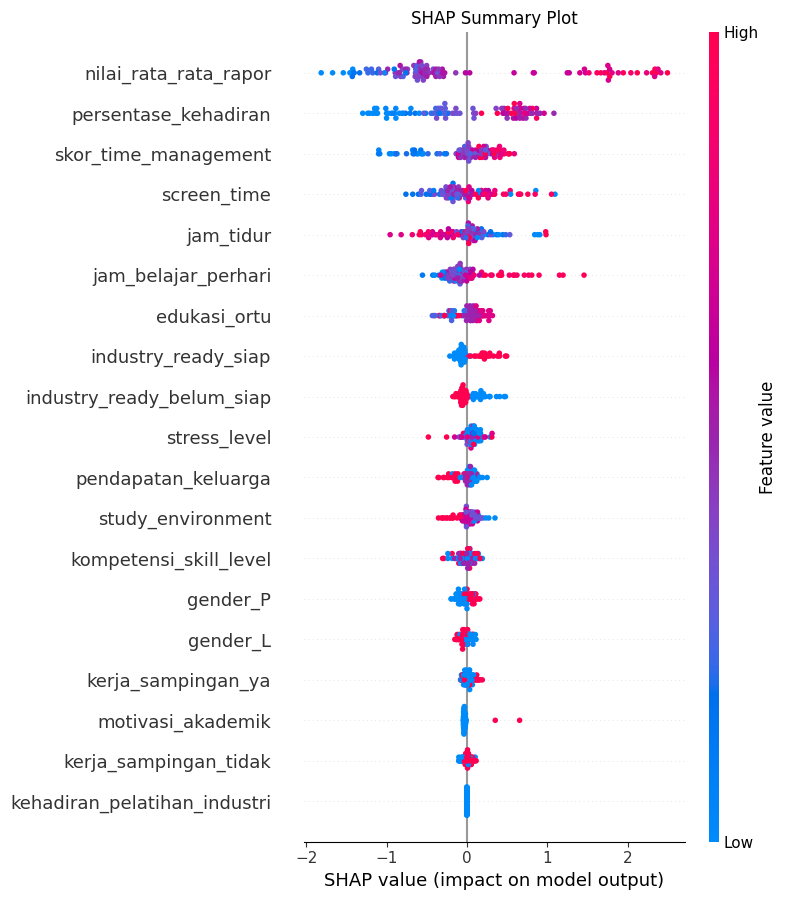

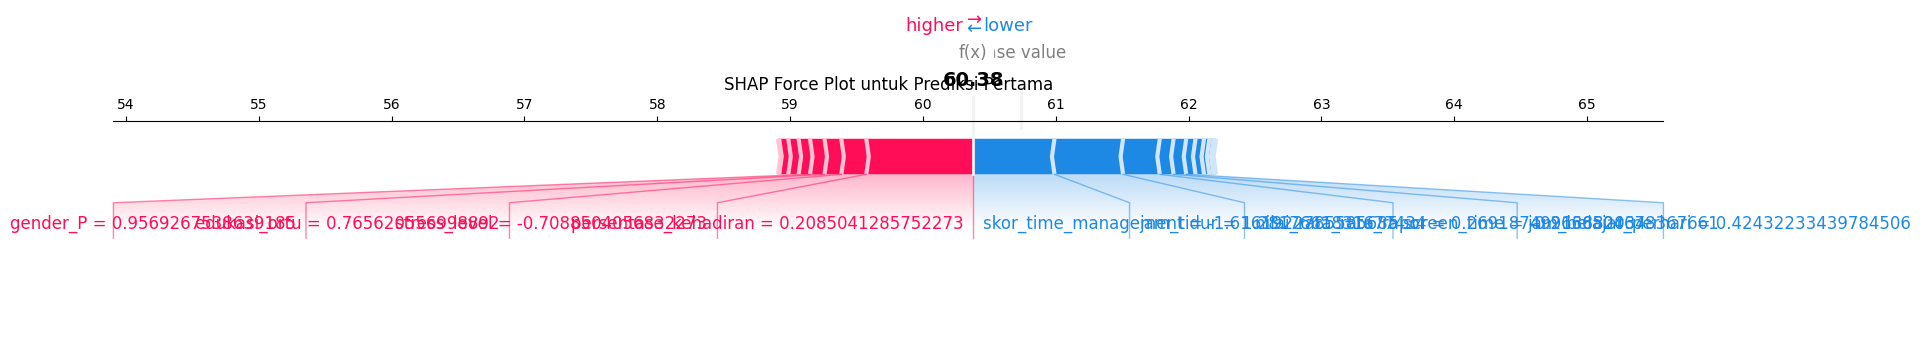

In [27]:
# ============================================
# 13. Interpretasi – SHAP
# ============================================
import shap

# Gunakan data training asli (X_train) untuk membangun explainer
# Karena SHAP untuk tree bisa menggunakan sampel background
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

# Global feature importance (mean absolute SHAP)
shap_mean_abs = np.abs(shap_values).mean(axis=0)
feature_importance_shap = pd.DataFrame({'feature': feature_names, 'shap_importance': shap_mean_abs})
feature_importance_shap = feature_importance_shap.sort_values('shap_importance', ascending=False)

print("\n===== Global Feature Importance (SHAP) =====")
print(feature_importance_shap.head(10))

# Plot summary
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

# Untuk prediksi individu (contoh pertama di X_test)
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:],
                feature_names=feature_names, matplotlib=True, show=False)
plt.title("SHAP Force Plot untuk Prediksi Pertama")
plt.savefig('shap_force_individual.png', bbox_inches='tight')
plt.show()

# Simpan SHAP values sebagai JSON (untuk endpoint API)
import json
shap_list = shap_values.tolist()  # hati-hati jika terlalu besar, bisa sampling
with open('shap_values.json', 'w') as f:
    json.dump(shap_list, f)

In [28]:
# ============================================
# 14. Penyimpanan Model (pickle)
# ============================================
import joblib

# Simpan model, scaler, dan encoder yang sudah dilatih
joblib.dump(rf_best, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Simpan ordinal encoder mapping? Untuk keperluan preprocessing di API, kita simpan objek encoder
# Tapi karena kita menggunakan OrdinalEncoder di atas, kita perlu menyimpannya juga.
# Kita buat dictionary encoders yang berisi semua transformer yang digunakan.
encoders = {
    'ordinal': {},
    'onehot': {}
}
# Untuk ordinal, kita simpan instance encoder (sudah fit)
ordinal_encoders = {}
for col, cats in ordinal_mappings.items():
    oe = OrdinalEncoder(categories=[cats])
    oe.fit(df[[col]])  # fit ulang pada data asli (pastikan urutan sama)
    ordinal_encoders[col] = oe
encoders['ordinal'] = ordinal_encoders

# Untuk one-hot, kita bisa simpan kolom-kolom hasil one-hot agar konsisten saat transform
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)  # atau drop_first=False sesuai pilihan
onehot_encoder.fit(df[nominal_cols])
encoders['onehot'] = onehot_encoder
encoders['nominal_cols'] = nominal_cols

joblib.dump(encoders, 'encoders.pkl')

# Juga simpan feature_names untuk konsistensi
joblib.dump(feature_names, 'feature_names.pkl')

print("\nModel dan preprocessor berhasil disimpan ke file.")

# Opsional: tampilkan contoh prediksi akhir
sample = X_test[0].reshape(1, -1)
pred_sample = rf_best.predict(sample)
print(f"\nContoh prediksi: nilai {pred_sample[0]:.2f} -> Kategori {'Rendah' if pred_sample[0]>=70 else 'Tinggi'}")


Model dan preprocessor berhasil disimpan ke file.

Contoh prediksi: nilai 60.38 -> Kategori Tinggi
